In [21]:
import pandas as pd
import folium
import matplotlib.pyplot as plt

from folium.plugins import HeatMap
from folium.features import DivIcon

In [49]:
# 1) Cargar registros del dataset minas antipersonal colombia
path = '../data/Situación_Víctimas_Minas_Antipersonal_en_Colombia_20260504.csv'
situacion_minas = pd.read_csv(path, encoding='utf-8', dtype=str)

In [50]:
print(situacion_minas.size)
print(situacion_minas.columns)
print(situacion_minas.head())

223020
Index(['departamento', 'codigodanedepartamento', 'municipio',
       'codigodanemunicipio', 'tipoarea', 'sitio', 'ano', 'mes', 'rangoedad',
       'grupoetnico', 'condicion', 'estado', 'genero', 'latitudcabecera',
       'longitudcabecera', 'tipoevento', 'Ubicación', 'Actividad'],
      dtype='str')
  departamento codigodanedepartamento    municipio codigodanemunicipio  \
0    ANTIOQUIA                      5      GRANADA               5.313   
1      CAQUETA                     18    MONTAÑITA              18.410   
2      BOLIVAR                     13       ARENAL              13.042   
3      BOLIVAR                     13       ARENAL              13.042   
4     PUTUMAYO                     86  PUERTO ASÍS              86.568   

  tipoarea            sitio    ano mes         rangoedad grupoetnico  \
0    Rural  Sin información  2.006   1  Mayor de 18 años          no   
1    Rural  Sin información  2.009  12  Mayor de 18 años          no   
2    Rural  Sin información  2.

In [24]:
# Limpiez de datase, cambiamos nombres y cambiamos el tipado
situacion_minas.rename(columns={'ano': 'año'}, inplace=True)
situacion_minas.rename(columns={'condicion': 'vinculación'}, inplace=True)
situacion_minas.rename(columns={'genero': 'condición'}, inplace=True)
situacion_minas.rename(columns={'estado': 'género'}, inplace=True)

# limpiar la columna año voliendolo str y removiendo . 
situacion_minas['año'] = situacion_minas['año'].astype(str).str.replace('.', '')
situacion_minas['latitudcabecera'] = situacion_minas['latitudcabecera'].astype(str).str.replace(',', '.')
situacion_minas['longitudcabecera'] = situacion_minas['longitudcabecera'].astype(str).str.replace(',', '.')


In [6]:
# Contar por departamento ordenar por cantidad
situacion_minas.groupby('departamento').size().sort_values(ascending=False)

departamento
ANTIOQUIA             2658
META                  1152
NARIÑO                1122
NORTE DE SANTANDER     970
CAQUETA                948
CAUCA                  672
ARAUCA                 656
BOLIVAR                647
TOLIMA                 539
PUTUMAYO               461
SANTANDER              297
CORDOBA                284
VALLE DEL CAUCA        271
GUAVIARE               267
HUILA                  239
CHOCO                  230
CALDAS                 173
CESAR                  156
CUNDINAMARCA           141
CASANARE                90
BOYACA                  78
SUCRE                   77
LA GUAJIRA              60
MAGDALENA               46
VAUPES                  44
BOGOTA DC               30
QUINDIO                 28
RISARALDA               22
VICHADA                 17
ATLANTICO                8
AMAZONAS                 4
GUAINIA                  3
dtype: int64

In [51]:
# contar cuantos registros hay en el dataset
print(f"Total de registros: {situacion_minas.shape[0]}")

Total de registros: 12390


In [25]:
# Contar por registro ordenar por year orden por año
situacion_minas.groupby('año').size().sort_index(ascending=False)

año
2023      85
2022     139
2021     157
2020     176
2019     117
2018     179
2017      59
2016      90
2015     223
2014     293
2013     427
2012     589
2011     564
2010     679
2009     771
2008     851
2007     980
2006    1224
2005    1176
2004     900
2003     760
2002     631
2001     299
2000     141
1999      54
1998      59
1997      96
1996     120
1995     130
1994      87
1993      88
1992     153
1991      70
1990      23
dtype: int64

<Axes: xlabel='año'>

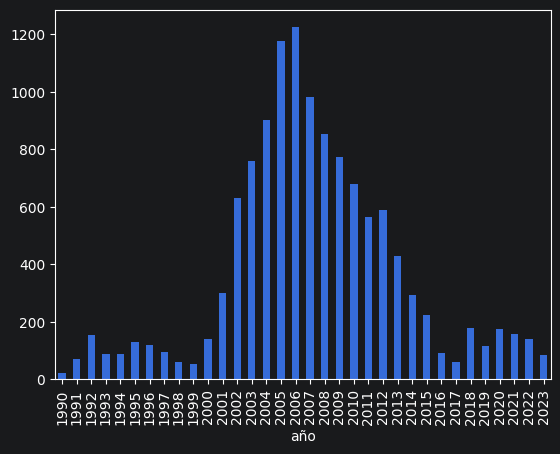

In [8]:
conteo_anio = situacion_minas.groupby('año').size().sort_index()
conteo_anio.plot(kind='bar', x='año', y='count')

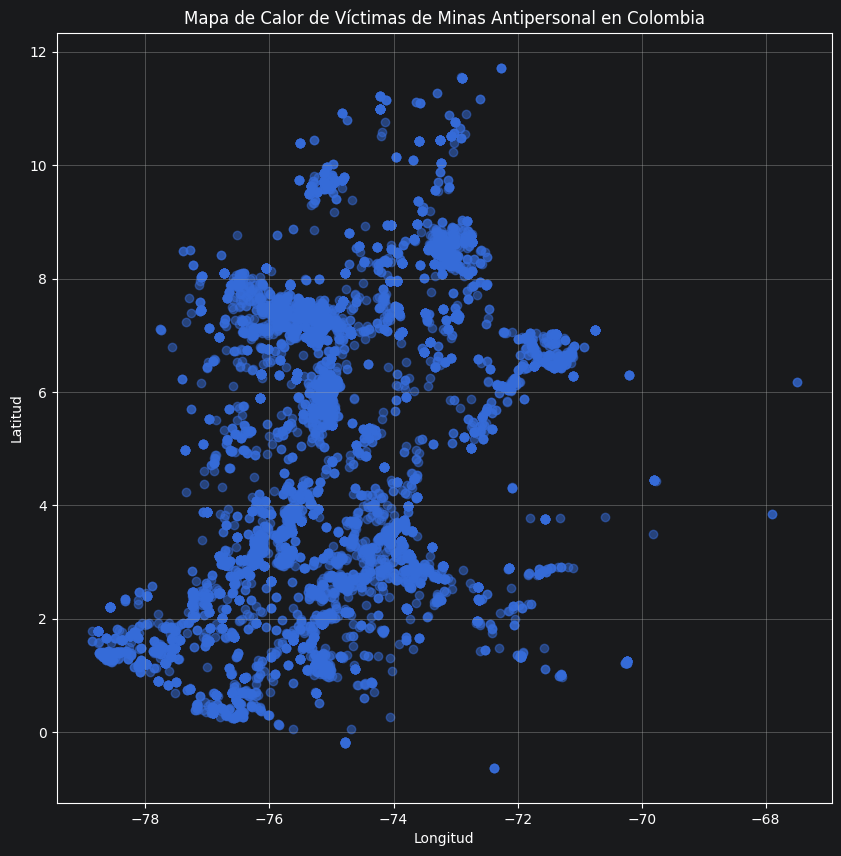

In [32]:
plt.figure(figsize=(10, 10))
plt.scatter(
    situacion_minas['longitudcabecera'].astype(float), 
    situacion_minas['latitudcabecera'].astype(float), 
    alpha=0.5
)
plt.title('Mapa de Calor de Víctimas de Minas Antipersonal en Colombia')
plt.xlabel('Longitud')
plt.ylabel('Latitud')

plt.grid()
plt.show()  


In [46]:
# filtrar año de 1990 a 2000 para mapa
situacion_minas_1990_2000 = situacion_minas[
    (situacion_minas['año'] >= '1990') &
    (situacion_minas['año'] <= '2000')
]

print(situacion_minas_1990_2000.shape[0])

mapa = folium.Map(location=[4.5709, -74.2973], zoom_start=6, tiles='CartoDB positron')
for index, row in situacion_minas_1990_2000.iterrows():
    if pd.notnull(row['latitudcabecera']) and pd.notnull(row['longitudcabecera']):
        folium.Marker(
            location=[float(row['latitudcabecera']), float(row['longitudcabecera'])],
            icon=folium.DivIcon(html='<div style="font-size:24px;">💥</div>')
        ).add_to(mapa)
mapa.save('mapa_victimas_minas_1990_2000.html')

1021


In [47]:
# filtrar ano de 2000 a 2016 para mapa
situacion_minas_2001_2015 = situacion_minas[
    (situacion_minas['año'] >= '2001') & 
    (situacion_minas['año'] <= '2015')
]
print(situacion_minas_2001_2015.shape[0])

mapa = folium.Map(location=[4.5709, -74.2973], zoom_start=6, tiles='CartoDB positron')
for index, row in situacion_minas_2001_2015.iterrows():
    if pd.notnull(row['latitudcabecera']) and pd.notnull(row['longitudcabecera']):
        folium.Marker(
            location=[float(row['latitudcabecera']), float(row['longitudcabecera'])],
            icon=folium.DivIcon(html='<div style="font-size:24px;">💥</div>')
        ).add_to(mapa)
mapa.save('mapa_victimas_minas_2001_2015.html')

10367


In [48]:
# filtrar ano de 2016 a 2023 para mapa
situacion_minas_2016_2023 = situacion_minas[
    (situacion_minas['año'] >= '2016') & 
    (situacion_minas['año'] <= '2023')
]
print(situacion_minas_2016_2023.shape[0])

mapa = folium.Map(location=[4.5709, -74.2973], zoom_start=6, tiles='CartoDB positron')
for index, row in situacion_minas_2016_2023.iterrows():
    if pd.notnull(row['latitudcabecera']) and pd.notnull(row['longitudcabecera']):
        folium.Marker(
            location=[float(row['latitudcabecera']), float(row['longitudcabecera'])],
            icon=folium.DivIcon(html='<div style="font-size:24px;">💥</div>')
        ).add_to(mapa)
mapa.save('mapa_victimas_minas_2016_2023.html')

1002


In [38]:
# Agrupar por vinculación (Civil  o fuerza publica)
(situacion_minas.groupby('vinculación').size()
 .sort_index(ascending=False))

vinculación
Fuerza pública    7368
Civil             5022
dtype: int64

In [39]:
# Contar por daño generado
(situacion_minas.groupby('condición').size()
 .sort_index(ascending=False))

condición
Muerto     2352
Herido    10038
dtype: int64

In [40]:
# Contar por grupo étnico
(situacion_minas.groupby('grupoetnico').size()
 .sort_index(ascending=False))

grupoetnico
no                  11772
Indigena              488
Afrodescendiente      130
dtype: int64

In [41]:
# Contar por rango de edad
(situacion_minas.groupby('rangoedad').size()
 .sort_index(ascending=False))

rangoedad
Menor de 18 años     1277
Mayor de 18 años    11113
dtype: int64

In [42]:
# Contar por genero étnico
(situacion_minas.groupby('género').size()
 .sort_index(ascending=False))

género
Sin Información       40
Mujer                673
Hombre             11677
dtype: int64

# atributos con fliltros adicionales

- Cuantos de los registros corresponden a civiles muertos ?
  ```
  condición = Muerto
  vinculacion = Civil
  ```

- Cuantos de los registros corresponden a menores de edad muertos?
  ```
  condición = Muerto
  rangoedad = Menor de 18 años
  ```

In [16]:
# ¿Cuántas vidas civiles se han perdido a causa de las minas antipersona?
situacion_minas[
    (situacion_minas['condición'] == 'Muerto') &
    (situacion_minas['vinculación'] == 'Civil')
].shape[0]

894

In [17]:
# ¿Cuántas vidas jóvenes se han perdido a causa de las minas antipersona?
situacion_minas[
    (situacion_minas['condición'] == 'Muerto') &
    (situacion_minas['rangoedad'] == 'Menor de 18 años')
].shape[0]

259

Detrás de cada dato existe una historia, una vida y un contexto humano que no siempre puede verse en una gráfica.